# III samba uued kogujad alates 2025-01-01

Kes need inimesed on, kes on Tulevas alustanud kogumist III sambast (perioodil 2025-01-01 → 2026-04-30) ja mida nad on pärast liitumist edasi teinud.

Allikad: Metabase cards 1519, 1520 (avalikud agregaadid) ja card 2345 (CRM).

In [1]:
import sys, os, json
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

project_root = Path.cwd().parents[1]
load_dotenv(project_root / '.env')
sys.path.insert(0, str(project_root / 'common' / 'scripts'))

from metabase_client import MetabaseClient
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

COLORS = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, '#B0D4F1']
COHORT_COLOR = TULEVA_NAVY
REFERENCE_COLOR = '#B0D4F1'

CACHE_DIR = Path(os.environ.get('TULEVA_CACHE_DIR', Path.home() / '.cache' / 'tuleva-reports'))
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')  # for benchmarks/tracked files only

COHORT_START = pd.Timestamp('2025-01-01')
COHORT_END   = pd.Timestamp('2026-04-30')

client = MetabaseClient()
print(f'Connected to {client.base_url}')
print(f'Cohort window: {COHORT_START.date()} → {COHORT_END.date()}')

Connected to https://metabase.tuleva.ee
Cohort window: 2025-01-01 → 2026-04-30


## 1. Avalik baseline — kui suur on cohort?

Card 1519 = II sambaga liitujate arv kuus. Card 1520 = III sambaga liitujate arv kuus. Veerg `'3'` cardis 1520 = inimesed, kes alustasid ainult III sambaga; `'2+3'` = mõlemaga korraga; `'2>3'` = lisas III, oli juba II-s.

Loeme baseline'i, et teaks, kui suure inimrühmaga tegu on.

In [2]:
raw_iii = client.execute_card(1520)
raw_ii  = client.execute_card(1519)
df_iii = pd.DataFrame(raw_iii)
df_ii  = pd.DataFrame(raw_ii)
print('III joiners columns:', list(df_iii.columns))
print(df_iii.head(3))
print('---')
print('II joiners columns:', list(df_ii.columns))
print(df_ii.head(3))

III joiners columns: ['kuu: Month', '2>3', '2+3', '3', 'YoY, %']
   kuu: Month  2>3  2+3    3    YoY, %
0  2025-04-01  127   27  314 -0.130112
1  2025-05-01   69   26  254 -0.114213
2  2025-06-01   56   30  240 -0.114130
---
II joiners columns: ['kuu: Month', '3>2', '2+3', '2', 'YoY, %']
   kuu: Month  3>2  2+3    2    YoY, %
0  2025-04-01   67   27  104 -0.081851
1  2025-05-01   85   26  111 -0.239852
2  2025-06-01   68   30  106 -0.213115


In [3]:
df_iii["kuu"] = pd.to_datetime(df_iii["kuu: Month"])
df_ii["kuu"]  = pd.to_datetime(df_ii["kuu: Month"])
baseline_start = df_iii["kuu"].min()
baseline_end   = df_iii["kuu"].max()
print(f"Avaliku baseline aken: {baseline_start.date()} -> {baseline_end.date()} ({len(df_iii)} kuud)")
print(f"Cohorti paring (card 2345) katab pikemat perioodi: {COHORT_START.date()} -> {COHORT_END.date()}")

iii_only_total = int(df_iii["3"].sum())
both_total     = int(df_iii["2+3"].sum())
ii_to_iii      = int(df_iii["2>3"].sum())
ii_only_total  = int(df_ii["2"].sum())
iii_to_ii      = int(df_ii["3>2"].sum())
all_new_total  = iii_only_total + both_total + ii_only_total + ii_to_iii + iii_to_ii

print(f"\nAvaliku baseline aknas ({baseline_start.date()} kuni {baseline_end.date()}):")
print(f"  Ainult III sambaga alustanud:   {iii_only_total:>6,}")
print(f"  II + III korraga:               {both_total:>6,}")
print(f"  Ainult II sambaga alustanud:    {ii_only_total:>6,}")
print(f"  III lisatud (oli juba II-s):    {ii_to_iii:>6,}")
print(f"  ---")
print(f"  III sambast alustanud kokku (3 + 2+3): {iii_only_total + both_total:,}")
print(f"  Osakaal koigist uutest kogujatest:     {(iii_only_total + both_total) / all_new_total * 100:.0f}%")

Avaliku baseline aken: 2025-04-01 -> 2026-04-01 (13 kuud)
Cohorti paring (card 2345) katab pikemat perioodi: 2025-01-01 -> 2026-04-30

Avaliku baseline aknas (2025-04-01 kuni 2026-04-01):
  Ainult III sambaga alustanud:    5,397
  II + III korraga:                  575
  Ainult II sambaga alustanud:     2,516
  III lisatud (oli juba II-s):     1,487
  ---
  III sambast alustanud kokku (3 + 2+3): 5,972
  Osakaal koigist uutest kogujatest:     50%


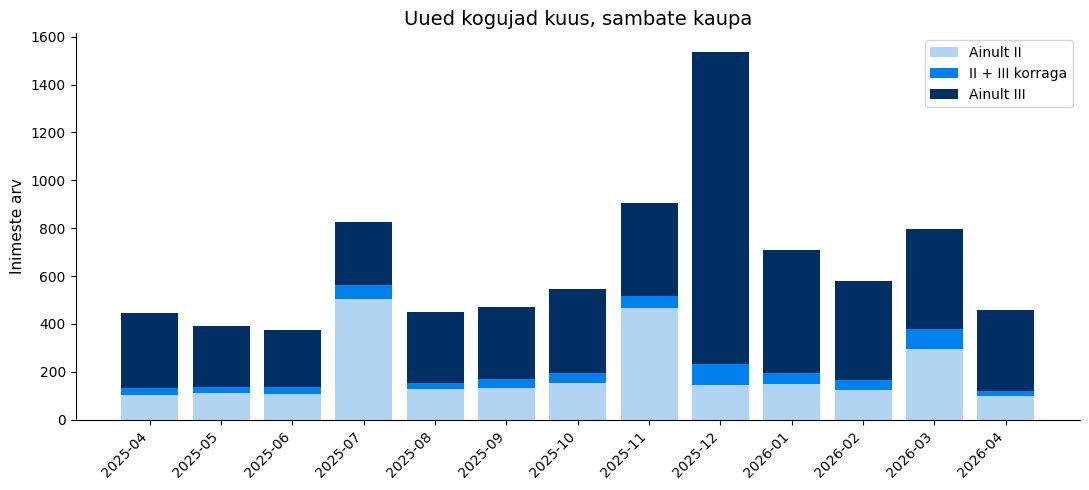

In [4]:
df_chart = df_iii.merge(df_ii[["kuu", "2"]], on="kuu", how="outer").sort_values("kuu")
df_chart = df_chart.fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
months = df_chart["kuu"].dt.strftime("%Y-%m")
ax.bar(months, df_chart["2"],   label="Ainult II",     color=REFERENCE_COLOR)
ax.bar(months, df_chart["2+3"], bottom=df_chart["2"],  label="II + III korraga", color=TULEVA_MID_BLUE)
ax.bar(months, df_chart["3"],   bottom=df_chart["2"]+df_chart["2+3"], label="Ainult III", color=COHORT_COLOR)
ax.set_title("Uued kogujad kuus, sambate kaupa")
ax.set_ylabel("Inimeste arv")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. CRM cohort — card 2345 skeem

Vaatame, milliseid välju card 2345 tagastab. Tuvastame III samba esimese sissemakse kuupäeva veeru, et cohort'i filtreerida.

In [5]:
CRM_CACHE = CACHE_DIR / "card_2345_crm.pkl"

if CRM_CACHE.exists():
    df_crm = pd.read_pickle(CRM_CACHE)
    print(f"Loaded cached CRM data: {len(df_crm):,} rows")
else:
    print("Fetching card 2345 from Metabase (may take a while)...")
    raw_crm = client.execute_card(2345)
    df_crm = pd.DataFrame(raw_crm)
    df_crm.to_pickle(CRM_CACHE)
    print(f"Fetched and cached: {len(df_crm):,} rows")

print(f"\nColumns ({len(df_crm.columns)}):")
for col in df_crm.columns:
    print(f"  {col!r:55s}  dtype={df_crm[col].dtype}")

Loaded cached CRM data: 97,702 rows

Columns (50):
  'Member Active'                                          dtype=object
  'Age'                                                    dtype=float64
  'Early Withdrawal Date'                                  dtype=str
  'Active In Tuk00'                                        dtype=bool
  'Last Transfer Out Date'                                 dtype=str
  'Latest Salary'                                          dtype=float64
  'Third Pillar Max Reporting Date'                        dtype=str
  'Third Pillar Last 12m Contributions Sum'                dtype=float64
  'Current Rate'                                           dtype=float64
  'Active In Tuk75'                                        dtype=bool
  'Capital Payment Done'                                   dtype=bool
  'Third Pillar All Shares Redeemed Date'                  dtype=str
  'ID Masked'                                              dtype=str
  'Tuk75 Current Aum'         

In [6]:
date_cols = [c for c in df_crm.columns if "Date" in c or "Month" in c]
for c in date_cols:
    df_crm[c] = pd.to_datetime(df_crm[c], errors="coerce")

df_crm["iii_min"] = df_crm["Third Pillar Min Contribution Date"]
df_crm["ii_first_in"] = df_crm[["Tuk75 Min Reporting Date", "Tuk00 Min Reporting Date"]].min(axis=1)
df_crm["any_min"] = df_crm[["iii_min", "ii_first_in"]].min(axis=1)

cohort_mask = (
    df_crm["iii_min"].notna()
    & (df_crm["iii_min"] >= COHORT_START)
    & (df_crm["iii_min"] <= COHORT_END)
)
cohort = df_crm[cohort_mask].copy()
print(f"Card 2345 ridu kokku: {len(df_crm):,}")
print(f"III samba esimene sissemakse {COHORT_START.date()} kuni {COHORT_END.date()}: {len(cohort):,}")

cohort["started_with_iii_only"] = (cohort["ii_first_in"].isna()) | (cohort["ii_first_in"] > cohort["iii_min"])
cohort["started_with_ii_too"]   = (cohort["ii_first_in"].notna()) & (cohort["ii_first_in"] <= cohort["iii_min"])

print(f"\n  Ainult III sambast alustanud:                {cohort['started_with_iii_only'].sum():>6,}")
print(f"  III alustamise hetkel oli juba II-s:        {cohort['started_with_ii_too'].sum():>6,}")

Card 2345 ridu kokku: 97,702
III samba esimene sissemakse 2025-01-01 kuni 2026-04-30: 8,319

  Ainult III sambast alustanud:                 6,421
  III alustamise hetkel oli juba II-s:         1,898


In [7]:
overlap_start = max(COHORT_START, baseline_start)
overlap_end_excl = baseline_end + pd.offsets.MonthBegin(1)

cohort_in_overlap = cohort[(cohort["iii_min"] >= overlap_start) & (cohort["iii_min"] < overlap_end_excl)]
baseline_iii_starters_in_overlap = iii_only_total + both_total

print(f"Sanity check, kattuv aken {overlap_start.date()} kuni {(overlap_end_excl - pd.Timedelta(days=1)).date()}:")
print(f"  Card 2345 cohort (III esimene sissemakse selles aknas): {len(cohort_in_overlap):,}")
print(f"  Card 1520 baseline (3 + 2+3):                           {baseline_iii_starters_in_overlap:,}")
diff_pct = (len(cohort_in_overlap) - baseline_iii_starters_in_overlap) / baseline_iii_starters_in_overlap * 100
print(f"  Erinevus: {diff_pct:+.1f}%  ({'OK' if abs(diff_pct) < 15 else 'KONTROLLI'})")

cohort_full = cohort.copy()
cohort_full.to_csv(CACHE_DIR / "iii_new_savers_cohort.csv", index=False)
print(f"\nSalvestatud: {CACHE_DIR / 'iii_new_savers_cohort.csv'} ({len(cohort_full):,} rida)")

Sanity check, kattuv aken 2025-04-01 kuni 2026-04-30:
  Card 2345 cohort (III esimene sissemakse selles aknas): 6,626
  Card 1520 baseline (3 + 2+3):                           5,972
  Erinevus: +11.0%  (OK)

Salvestatud: /Users/tonupekk/.cache/tuleva-reports/iii_new_savers_cohort.csv (8,319 rida)


In [8]:
cohort_strict = cohort[cohort["started_with_iii_only"]].copy()
print(f"Pohcohort = inimesed, kelle esimene Tuleva sissemakse oli III sambasse")
print(f"  Kogu cohort (III min {COHORT_START.date()} kuni {COHORT_END.date()}): {len(cohort_strict):,}")

strict_in_overlap = cohort_strict[(cohort_strict["iii_min"] >= overlap_start) & (cohort_strict["iii_min"] < overlap_end_excl)]
print(f"\nKattuvas aknas:")
print(f"  Card 2345 strict cohort: {len(strict_in_overlap):,}")
print(f"  Card 1520 ['3']:         {iii_only_total:,}")
diff = (len(strict_in_overlap) - iii_only_total) / iii_only_total * 100
print(f"  Erinevus: {diff:+.1f}%")

cohort_strict.to_csv(CACHE_DIR / "iii_new_savers_cohort_strict.csv", index=False)

Pohcohort = inimesed, kelle esimene Tuleva sissemakse oli III sambasse
  Kogu cohort (III min 2025-01-01 kuni 2026-04-30): 6,421

Kattuvas aknas:
  Card 2345 strict cohort: 5,081
  Card 1520 ['3']:         5,397
  Erinevus: -5.9%


## 3. Demograafia

Sugu, vanus, sissetulek. Võrdleme cohorti ülejäänud Tuleva III samba kogujatega — kontrollime, kas uued tulijad erinevad olemasolevatest.

**Cohort** = inimesed, kelle esimene Tuleva sissemakse oli III sambasse, ajavahemikus 2025-01-01 → 2026-04-30 (n = 6,421).

**Referents** = kõik teised Tuleva III samba kogujad, kelle III samba esimene sissemakse oli enne 2025-01-01.

In [9]:
reference = df_crm[df_crm["iii_min"].notna() & (df_crm["iii_min"] < COHORT_START)].copy()
print(f"Cohort:    {len(cohort_strict):,} inimest")
print(f"Referents: {len(reference):,} inimest (varasemad III samba kogujad)")

def gender_share(df):
    s = df["Gender"].fillna("Teadmata").str.upper().replace({"M": "Mees", "F": "Naine"})
    return s.value_counts(normalize=True) * 100

g_cohort = gender_share(cohort_strict)
g_ref    = gender_share(reference)
gender_df = pd.DataFrame({"Cohort %": g_cohort, "Referents %": g_ref}).fillna(0)
print("\nSugu:")
print(gender_df.round(1))

Cohort:    6,421 inimest
Referents: 65,602 inimest (varasemad III samba kogujad)



Sugu:
        Cohort %  Referents %
Gender                       
Naine       58.8         56.6
Mees        41.2         43.4


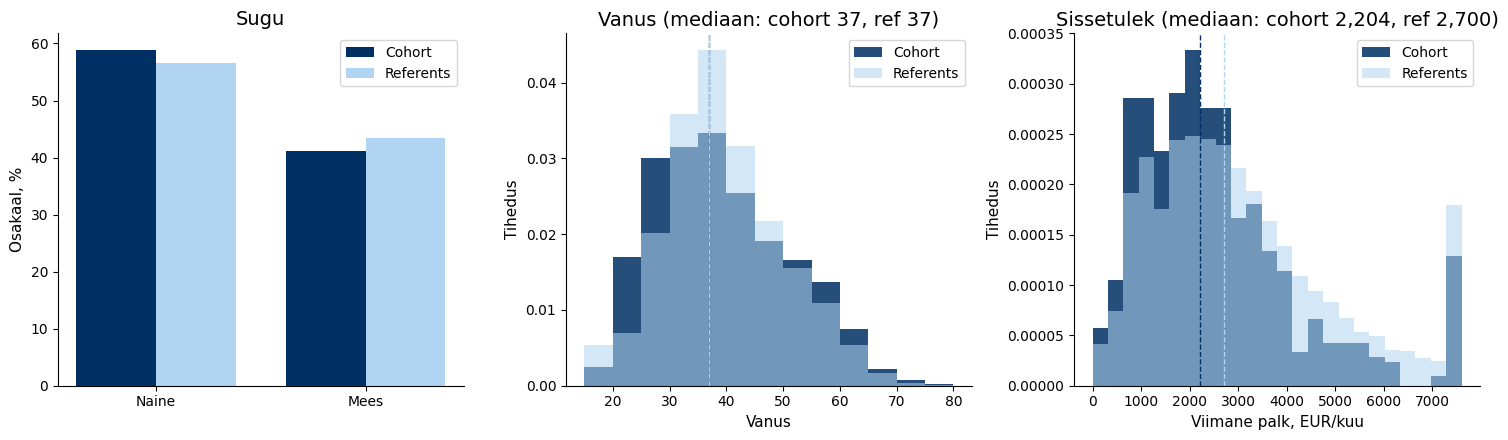


Vanus:       cohort mediaan 37a, referents 37a
Sissetulek:  cohort mediaan 2,204 EUR, referents 2,700 EUR
Sissetulek:  cohort keskmine 2,658 EUR, referents 3,274 EUR
Palga andmeid puudub: cohort 90%, ref 56%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
x = np.arange(len(gender_df.index))
w = 0.38
ax.bar(x - w/2, gender_df["Cohort %"],    width=w, label="Cohort",    color=COHORT_COLOR)
ax.bar(x + w/2, gender_df["Referents %"], width=w, label="Referents", color=REFERENCE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(gender_df.index)
ax.set_ylabel("Osakaal, %")
ax.set_title("Sugu")
ax.legend()

ax = axes[1]
age_bins = list(range(15, 81, 5))
ax.hist(cohort_strict["Age"].dropna(), bins=age_bins, density=True, color=COHORT_COLOR, alpha=0.85, label="Cohort")
ax.hist(reference["Age"].dropna(),     bins=age_bins, density=True, color=REFERENCE_COLOR, alpha=0.55, label="Referents")
med_c = cohort_strict["Age"].median()
med_r = reference["Age"].median()
ax.axvline(med_c, color=COHORT_COLOR, linestyle="--", linewidth=1)
ax.axvline(med_r, color=REFERENCE_COLOR, linestyle="--", linewidth=1)
ax.set_xlabel("Vanus")
ax.set_ylabel("Tihedus")
ax.set_title(f"Vanus (mediaan: cohort {med_c:.0f}, ref {med_r:.0f})")
ax.legend()

ax = axes[2]
sal_cohort = cohort_strict["Latest Salary"].dropna()
sal_ref    = reference["Latest Salary"].dropna()
sal_cap = np.nanpercentile(np.concatenate([sal_cohort.values, sal_ref.values]), 95)
sal_bins = np.linspace(0, sal_cap, 25)
ax.hist(sal_cohort.clip(upper=sal_cap), bins=sal_bins, density=True, color=COHORT_COLOR, alpha=0.85, label="Cohort")
ax.hist(sal_ref.clip(upper=sal_cap),    bins=sal_bins, density=True, color=REFERENCE_COLOR, alpha=0.55, label="Referents")
med_sc = sal_cohort.median()
med_sr = sal_ref.median()
ax.axvline(med_sc, color=COHORT_COLOR, linestyle="--", linewidth=1)
ax.axvline(med_sr, color=REFERENCE_COLOR, linestyle="--", linewidth=1)
ax.set_xlabel("Viimane palk, EUR/kuu")
ax.set_ylabel("Tihedus")
ax.set_title(f"Sissetulek (mediaan: cohort {med_sc:,.0f}, ref {med_sr:,.0f})")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nVanus:       cohort mediaan {cohort_strict['Age'].median():.0f}a, referents {reference['Age'].median():.0f}a")
print(f"Sissetulek:  cohort mediaan {sal_cohort.median():,.0f} EUR, referents {sal_ref.median():,.0f} EUR")
print(f"Sissetulek:  cohort keskmine {sal_cohort.mean():,.0f} EUR, referents {sal_ref.mean():,.0f} EUR")
print(f"Palga andmeid puudub: cohort {cohort_strict['Latest Salary'].isna().mean()*100:.0f}%, ref {reference['Latest Salary'].isna().mean()*100:.0f}%")

## 4. Käitumine pärast liitumist

Mida cohort on Tulevas teinud alates III samba esimesest sissemaksest:

- **III samba sissemaksed** — kogusumma, viimane 12 kuud, püsimakse osakaal
- **III samba praegune varasaldo**
- **II sammas** — kas tõid II samba Tulevasse pärast III sambaga liitumist
- **Maksemäära muutmine** — palju on tõstetud (Current vs Next Rate)
- **Lahkumised** — III samba kõikide osakute lunastamine, varade ületoomine kindlustusse
- **Vara väljavõtmised** — early withdrawal staatus

Kõik arvud on cohort'i kohta (n = 6,421).

In [11]:
n = len(cohort_strict)

iii_aum_total = cohort_strict["Third Pillar Current Aum"].sum()
iii_l12m_total = cohort_strict["Third Pillar Last 12m Contributions Sum"].sum()
iii_aum_median = cohort_strict["Third Pillar Current Aum"].median()
iii_l12m_median = cohort_strict["Third Pillar Last 12m Contributions Sum"].median()
recurring = cohort_strict["Recurring Payment"].sum()
balance_iii = cohort_strict["Balance In Third Pillar"].sum()

print("=== III samba sissemaksed ja varasaldo ===")
print(f"  III samba praegune AUM kokku:                  {iii_aum_total/1e6:>8,.2f} M EUR")
print(f"  III samba mediaan saldo:                       {iii_aum_median:>8,.0f} EUR")
print(f"  Viimase 12 kuu sissemaksed kokku:              {iii_l12m_total/1e6:>8,.2f} M EUR")
print(f"  Viimase 12 kuu sissemaksete mediaan:           {iii_l12m_median:>8,.0f} EUR/inimene")
print(f"  Püsimaksega inimesi:                           {recurring:>5,} ({recurring/n*100:.0f}%)")
print(f"  III samba saldo > 0 (st pole täielikult välja võtnud): {balance_iii:>5,} ({balance_iii/n*100:.0f}%)")

=== III samba sissemaksed ja varasaldo ===
  III samba praegune AUM kokku:                     14.14 M EUR
  III samba mediaan saldo:                            624 EUR
  Viimase 12 kuu sissemaksed kokku:                  7.82 M EUR
  Viimase 12 kuu sissemaksete mediaan:                500 EUR/inimene
  Püsimaksega inimesi:                           1,754 (27%)
  III samba saldo > 0 (st pole täielikult välja võtnud): 6,288 (98%)


In [12]:
left_ii_system = cohort_strict["Early Withdrawal Status"].isin(["R", "A"])
n_left_ii_system = left_ii_system.sum()
n_eligible_for_ii = n - n_left_ii_system

added_ii_after = (
    cohort_strict["ii_first_in"].notna()
    & (cohort_strict["ii_first_in"] > cohort_strict["iii_min"])
)
n_added_ii = added_ii_after.sum()
ii_aum_added = cohort_strict.loc[added_ii_after, ["Tuk75 Current Aum", "Tuk00 Current Aum"]].sum().sum()

active_ii = cohort_strict[["Active In Tuk75", "Active In Tuk00"]].any(axis=1).sum()
balance_ii = cohort_strict[["Balance In Tuk75", "Balance In Tuk00"]].any(axis=1).sum()

print("=== II samba ületoomine III sambaga liitumise jarel ===")
print(f"  Kogu cohort:                                          {n:>5,}")
print(f"  ... kellest II sambast lahkunud (Early Withdrawal R/A): {n_left_ii_system:>5,} ({n_left_ii_system/n*100:.0f}%)  - II sammast pole, ei saagi tuua")
print(f"  ... kellele II samba ületoomine on uberhaupt voimalik: {n_eligible_for_ii:>5,}")
print()
print(f"  Tõid II samba Tulevasse pärast III samba liitumist:   {n_added_ii:>5,}")
print(f"    osakaal kogu cohort'ist:           {n_added_ii/n*100:.0f}%")
print(f"    osakaal voimalikest (mitte-R/A):  {n_added_ii/n_eligible_for_ii*100:.0f}%")
print(f"  Nende II samba praegune AUM kokku:  {ii_aum_added/1e6:.2f} M EUR")
print()
print(f"  Aktiivne Tuleva II sambas (mistahes hetkel):  {active_ii:>5,} ({active_ii/n*100:.0f}%)")
print(f"  Tuleva II sambas mingi varasaldo:             {balance_ii:>5,} ({balance_ii/n*100:.0f}%)")

=== II samba ületoomine III sambaga liitumise jarel ===
  Kogu cohort:                                          6,421
  ... kellest II sambast lahkunud (Early Withdrawal R/A): 1,795 (28%)  - II sammast pole, ei saagi tuua
  ... kellele II samba ületoomine on uberhaupt voimalik: 4,626

  Tõid II samba Tulevasse pärast III samba liitumist:     894
    osakaal kogu cohort'ist:           14%
    osakaal voimalikest (mitte-R/A):  19%
  Nende II samba praegune AUM kokku:  7.72 M EUR

  Aktiivne Tuleva II sambas (mistahes hetkel):    811 (13%)
  Tuleva II sambas mingi varasaldo:               696 (11%)


In [13]:
cur = cohort_strict["Current Rate"]
nxt = cohort_strict["Next Rate"]
has_rate = cur.notna()
rate_inc = has_rate & nxt.notna() & (nxt > cur)
rate_dec = has_rate & nxt.notna() & (nxt < cur)
rate_to_6 = has_rate & nxt.notna() & (nxt == 6) & (cur < 6)

print("=== II samba maksemäära muutmine ===")
print(f"  Cohort'is on II samba maksemäär kirjas:        {has_rate.sum():>5,} ({has_rate.sum()/n*100:.0f}% cohort'ist)")
print(f"  Maksemäära tõstnud (Next Rate > Current Rate): {rate_inc.sum():>5,}")
print(f"  Maksemäära langetanud:                         {rate_dec.sum():>5,}")
print(f"  Tõstnud just 6%-ni:                            {rate_to_6.sum():>5,}")
if has_rate.sum() > 0:
    print(f"\n  Praegune maksemäär (jaotus, % cohort'ist):")
    print((cur.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

=== II samba maksemäära muutmine ===
  Cohort'is on II samba maksemäär kirjas:        6,095 (95% cohort'ist)
  Maksemäära tõstnud (Next Rate > Current Rate):   321
  Maksemäära langetanud:                            37
  Tõstnud just 6%-ni:                              218

  Praegune maksemäär (jaotus, % cohort'ist):
Current Rate
2.0    66.5
4.0     9.9
6.0    23.6


### III samba sissemaksed vahemike kaupa + seos II samba maksemääraga

Vaatame, kui aktiivsed cohort III samba kogujad on (viimase 12 kuu sissemaksed) ja kas suuremad III samba sissemaksed käivad käsikäes II samba kõrgema maksemääraga.

In [14]:
bucket_edges  = [-0.01, 100, 1000, 2000, np.inf]
bucket_labels = ["alla 100", "100-1000", "1000-2000", "ule 2000"]
cohort_strict["iii_l12m_bucket"] = pd.cut(
    cohort_strict["Third Pillar Last 12m Contributions Sum"].fillna(0),
    bins=bucket_edges, labels=bucket_labels
)

bucket_summary = cohort_strict.groupby("iii_l12m_bucket", observed=True).agg(
    inimesi=("ID Masked", "count"),
    sissemaksed_M=("Third Pillar Last 12m Contributions Sum", lambda s: s.sum()/1e6),
    aum_M=("Third Pillar Current Aum", lambda s: s.sum()/1e6),
    pusimakse_pct=("Recurring Payment", lambda s: s.mean()*100),
).reindex(bucket_labels)
bucket_summary["osakaal_pct"] = bucket_summary["inimesi"] / n * 100

print("=== III samba viimase 12 kuu sissemaksed - vahemike kaupa ===")
print(bucket_summary[["inimesi", "osakaal_pct", "sissemaksed_M", "aum_M", "pusimakse_pct"]].round(2).to_string())
print(f"\n  Kokku: {n:,} inimest, {cohort_strict['Third Pillar Last 12m Contributions Sum'].sum()/1e6:.2f} M EUR sissemakseid 12 kuu jooksul")

=== III samba viimase 12 kuu sissemaksed - vahemike kaupa ===
                 inimesi  osakaal_pct  sissemaksed_M  aum_M  pusimakse_pct
iii_l12m_bucket                                                           
alla 100            1367        21.29           0.06   0.40           4.83
100-1000            3068        47.78           1.33   2.77          32.82
1000-2000            825        12.85           1.21   2.19          41.82
ule 2000            1161        18.08           5.21   8.77          28.94

  Kokku: 6,421 inimest, 7.82 M EUR sissemakseid 12 kuu jooksul


=== Inimeste arv: III samba sissemakse vs II samba maksemäär ===
ii_rate_grp      II sambast lahkunud    2%   4%   6%
iii_l12m_bucket                                     
alla 100                         458   563   93  177
100-1000                         986  1126  294  545
1000-2000                        177   306   65  226
ule 2000                         174   413  101  391

=== % cohort'ist (kokku 100%) ===
ii_rate_grp      II sambast lahkunud    2%   4%   6%
iii_l12m_bucket                                     
alla 100                         7.5   9.2  1.5  2.9
100-1000                        16.2  18.5  4.8  8.9
1000-2000                        2.9   5.0  1.1  3.7
ule 2000                         2.9   6.8  1.7  6.4


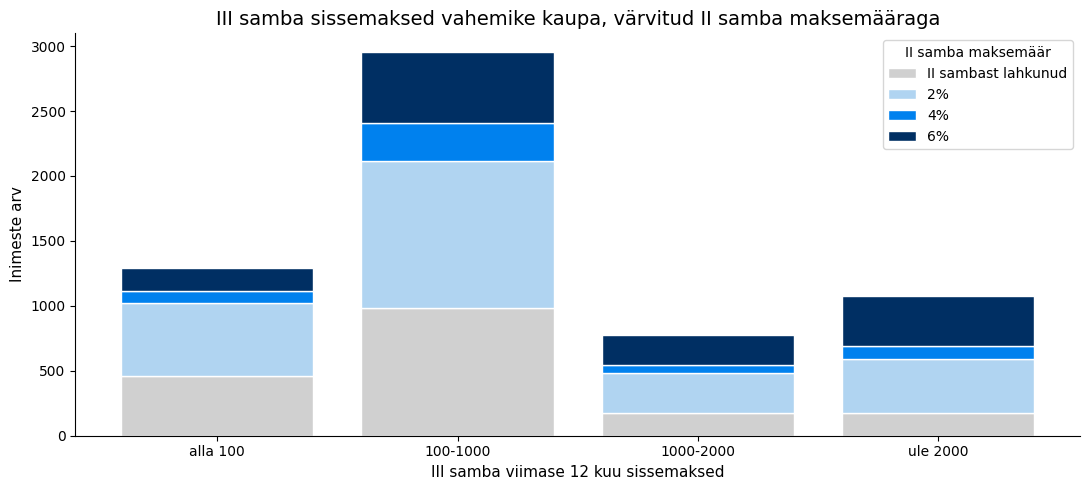

In [15]:
cohort_strict["ii_rate_grp"] = cohort_strict["Current Rate"].map({2.0: "2%", 4.0: "4%", 6.0: "6%"})
cohort_strict.loc[left_ii_system, "ii_rate_grp"] = "II sambast lahkunud"

rate_order = ["II sambast lahkunud", "2%", "4%", "6%"]
crosstab = pd.crosstab(
    cohort_strict["iii_l12m_bucket"],
    cohort_strict["ii_rate_grp"],
).reindex(index=bucket_labels, columns=rate_order, fill_value=0)
crosstab_pct = crosstab.div(crosstab.values.sum()) * 100

print("=== Inimeste arv: III samba sissemakse vs II samba maksemäär ===")
print(crosstab.to_string())
print("\n=== % cohort'ist (kokku 100%) ===")
print(crosstab_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(bucket_labels))
colors_rate = ["#D0D0D0", REFERENCE_COLOR, TULEVA_MID_BLUE, COHORT_COLOR]
for grp, color in zip(rate_order, colors_rate):
    vals = crosstab[grp].values
    ax.bar(bucket_labels, vals, bottom=bottom, label=grp, color=color, edgecolor="white")
    bottom += vals
ax.set_xlabel("III samba viimase 12 kuu sissemaksed")
ax.set_ylabel("Inimeste arv")
ax.set_title("III samba sissemaksed vahemike kaupa, värvitud II samba maksemääraga")
ax.legend(title="II samba maksemäär")
plt.tight_layout()
plt.show()

In [16]:
iii_redeemed = cohort_strict["Third Pillar All Shares Redeemed Date"].notna().sum()
iii_no_balance = (~cohort_strict["Balance In Third Pillar"].fillna(False)).sum()
early_w = cohort_strict["Early Withdrawal Date"].notna().sum()
ew_status = cohort_strict["Early Withdrawal Status"].fillna("Pole").value_counts()

print("=== Lahkumised ja vara väljavõtmised ===")
print(f"  III samba kõik osakud lunastatud:   {iii_redeemed:>5,} ({iii_redeemed/n*100:.1f}%)")
print(f"  III sambas saldot pole (üldse):     {iii_no_balance:>5,} ({iii_no_balance/n*100:.1f}%)")
print(f"  Early Withdrawal kuupäev olemas:    {early_w:>5,} ({early_w/n*100:.1f}%)")
print(f"\n  Early Withdrawal Status jaotus:")
for status, count in ew_status.items():
    print(f"    {status:30s}  {count:>5,} ({count/n*100:.1f}%)")

=== Lahkumised ja vara väljavõtmised ===
  III samba kõik osakud lunastatud:     156 (2.4%)
  III sambas saldot pole (üldse):       133 (2.1%)
  Early Withdrawal kuupäev olemas:    1,795 (28.0%)

  Early Withdrawal Status jaotus:
    Pole                            4,626 (72.0%)
    R                               1,723 (26.8%)
    A                                  72 (1.1%)


### Persona mapping — cohort vs savers_analysis raamistik

Rakendan `savers_analysis.ipynb` 5 persona definitsiooni cohort'ile. Mõned kohaldused:

- **Has Both Pillars** = on II sambas (kas Tulevas või mujal). Kui Early Withdrawal R/A → ei ole.
- **Voluntary Rate** = II samba praegune maksemäär > 2%
- **III Annual Contrib** = viimase 12 kuu III sissemaksed (lähim olemasolev mõõdik)
- **Total AUM** = Tuleva III + Tuleva II AUM (mujal hoitavat II vara card 2345 ei näita)

Definitsioonid:
- **Power Saver**: mõlemad sambad + vabatahtlik (>2%) maksemäär + III ≥ 2,400 EUR/aastas
- **Steady Saver**: mõlemad sambad + (vabatahtlik määr või III sissemakse > 0)
- **Coaster**: mõlemad sambad, aga ei sissemakset ega vabatahtlikku määra
- **Single Pillar**: ainult III (sh kõik R/A staatusega — II sambast lahkunud)
- **Gone**: Tulevas vara = 0

In [17]:
cs = cohort_strict
cs["has_both_pillars"] = ~left_ii_system
cs["voluntary_rate"]   = (cs["Current Rate"].fillna(0) > 2)
cs["iii_annual"]       = cs["Third Pillar Last 12m Contributions Sum"].fillna(0)
cs["total_tuleva_aum"] = cs[["Third Pillar Current Aum", "Tuk75 Current Aum", "Tuk00 Current Aum"]].sum(axis=1)

def persona(row):
    if row["total_tuleva_aum"] == 0:
        return "Gone"
    if row["has_both_pillars"] and row["voluntary_rate"] and row["iii_annual"] >= 2400:
        return "Power Saver"
    if row["has_both_pillars"] and (row["voluntary_rate"] or row["iii_annual"] > 0):
        return "Steady Saver"
    if row["has_both_pillars"]:
        return "Coaster"
    return "Single Pillar"

cs["Persona"] = cs.apply(persona, axis=1)

PERSONA_ORDER  = ["Power Saver", "Steady Saver", "Coaster", "Single Pillar", "Gone"]
PERSONA_COLORS = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, "#B0D4F1", "#D0D0D0"]

rows = []
for p in PERSONA_ORDER:
    sub = cs[cs["Persona"] == p]
    rows.append({
        "Persona": p,
        "inimesi": len(sub),
        "%": len(sub) / n * 100,
        "AUM (M EUR)": sub["total_tuleva_aum"].sum() / 1e6,
        "% AUM": sub["total_tuleva_aum"].sum() / cs["total_tuleva_aum"].sum() * 100 if cs["total_tuleva_aum"].sum() else 0,
        "Mediaan vanus": sub["Age"].median(),
        "Mediaan III L12m": sub["iii_annual"].median(),
        "Vabatahtlik maar %": sub["voluntary_rate"].mean() * 100,
    })
persona_tbl = pd.DataFrame(rows)
print("=== Cohort persona jaotus ===")
print(persona_tbl.round(1).to_string(index=False))

=== Cohort persona jaotus ===
      Persona  inimesi    %  AUM (M EUR)  % AUM  Mediaan vanus  Mediaan III L12m  Vabatahtlik maar %
  Power Saver      444  6.9          5.9   26.9           41.0            4200.0               100.0
 Steady Saver     4013 62.5         13.5   61.7           36.0             480.0                35.4
      Coaster       81  1.3          0.3    1.5           31.0               0.0                 0.0
Single Pillar     1734 27.0          2.1    9.8           39.0             300.0                 8.2
         Gone      149  2.3          0.0    0.0           36.0             150.0                24.8


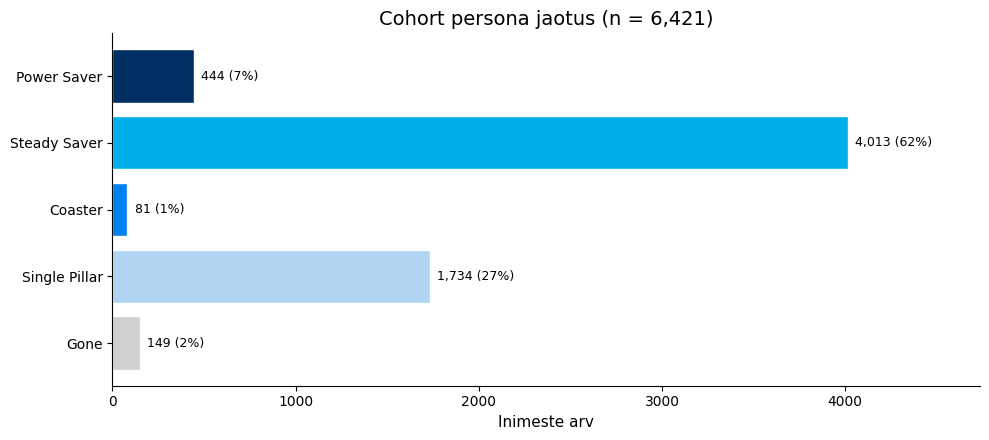

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(PERSONA_ORDER))
counts = [persona_tbl.set_index("Persona").loc[p, "inimesi"] for p in PERSONA_ORDER]
pcts   = [persona_tbl.set_index("Persona").loc[p, "%"] for p in PERSONA_ORDER]
bars = ax.barh(y, counts, color=PERSONA_COLORS, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(PERSONA_ORDER)
ax.invert_yaxis()
ax.set_xlabel("Inimeste arv")
ax.set_title(f"Cohort persona jaotus (n = {n:,})")
for bar, c, p in zip(bars, counts, pcts):
    ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f"{c:,} ({p:.0f}%)", va="center", fontsize=9)
ax.set_xlim(0, max(counts) * 1.18)
plt.tight_layout()
plt.show()

## 5. Inimtüüpide süntees

Hüpotees: cohort'is domineerivad (a) noored (20-40a), kes alustavad III sambast esmase pensionivahendina, ja (b) inimesed, kes on II samba välja võtnud ja kasutavad nüüd III sammast. Vaatame, kas need grupid kattuvad ja milline säästukäitumine eri segmentides domineerib.

In [19]:
age_bins  = [0, 20, 30, 40, 50, 60, 200]
age_labels = ["alla 20", "20-29", "30-39", "40-49", "50-59", "60+"]
cs["age_grp"] = pd.cut(cs["Age"], bins=age_bins, labels=age_labels, right=False)
cs["ii_status"] = np.where(left_ii_system, "II valja votnud (R/A)", "II sambas")

age_dist = cs["age_grp"].value_counts().reindex(age_labels)
print("=== Vanuse jaotus cohort'is ===")
for a, c in zip(age_labels, age_dist.fillna(0).astype(int)):
    print(f"  {a:8s}  {c:>5,}  ({c/n*100:>4.1f}%)")
print(f"  20-39 vahemikus kokku: {(cs['age_grp'].isin(['20-29','30-39'])).sum():,} ({(cs['age_grp'].isin(['20-29','30-39'])).mean()*100:.0f}%)")
print()

print("=== Vanus x II samba staatus (inimeste arv) ===")
ct = pd.crosstab(cs["age_grp"], cs["ii_status"]).reindex(age_labels)
print(ct.to_string())
print()
print("=== Vanus x II samba staatus (% reast - kui suur osa selles vanuses on II valja votnud) ===")
ct_row = pd.crosstab(cs["age_grp"], cs["ii_status"], normalize="index").reindex(age_labels) * 100
print(ct_row.round(1).to_string())

=== Vanuse jaotus cohort'is ===
  alla 20     103  ( 1.6%)
  20-29     1,503  (23.4%)
  30-39     2,075  (32.3%)
  40-49     1,425  (22.2%)
  50-59       967  (15.1%)
  60+         348  ( 5.4%)
  20-39 vahemikus kokku: 3,578 (56%)

=== Vanus x II samba staatus (inimeste arv) ===
ii_status  II sambas  II valja votnud (R/A)
age_grp                                    
alla 20          103                      0
20-29           1304                    199
30-39           1297                    778
40-49            902                    523
50-59            701                    266
60+              319                     29

=== Vanus x II samba staatus (% reast - kui suur osa selles vanuses on II valja votnud) ===
ii_status  II sambas  II valja votnud (R/A)
age_grp                                    
alla 20        100.0                    0.0
20-29           86.8                   13.2
30-39           62.5                   37.5
40-49           63.3                   36.7
50-59      

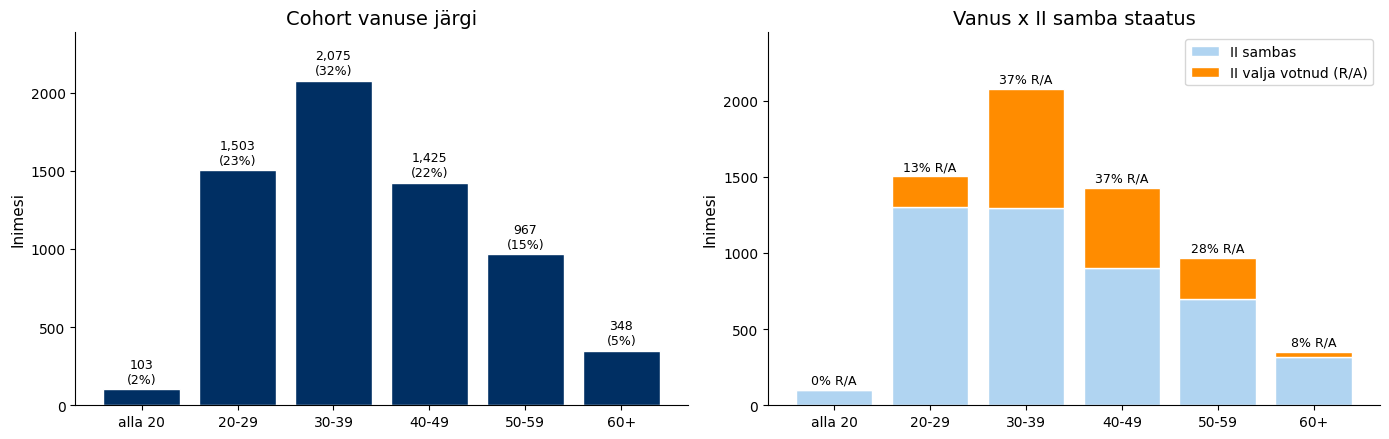

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.bar(age_labels, age_dist.fillna(0).values, color=COHORT_COLOR, edgecolor="white")
for i, v in enumerate(age_dist.fillna(0).values):
    ax.text(i, v + max(age_dist)*0.02, f"{int(v):,}\n({v/n*100:.0f}%)", ha="center", fontsize=9)
ax.set_ylabel("Inimesi")
ax.set_title("Cohort vanuse järgi")
ax.set_ylim(0, max(age_dist) * 1.15)

ax = axes[1]
in_ii = ct["II sambas"].values
out_ii = ct["II valja votnud (R/A)"].values
ax.bar(age_labels, in_ii,   label="II sambas",      color=REFERENCE_COLOR, edgecolor="white")
ax.bar(age_labels, out_ii, bottom=in_ii, label="II valja votnud (R/A)", color="#FF8C00", edgecolor="white")
for i, (a, b) in enumerate(zip(in_ii, out_ii)):
    if (a+b) > 0:
        ax.text(i, a+b + max(in_ii+out_ii)*0.02, f"{b/(a+b)*100:.0f}% R/A", ha="center", fontsize=9)
ax.set_ylabel("Inimesi")
ax.set_title("Vanus x II samba staatus")
ax.legend()
ax.set_ylim(0, max(in_ii+out_ii) * 1.18)

plt.tight_layout()
plt.show()

In [21]:
passive = (cs["Current Rate"].fillna(0) <= 2) & (cs["iii_annual"] < 1000) & ~left_ii_system
active  = (cs["voluntary_rate"]) | (cs["iii_annual"] >= 1000)
single_pillar = left_ii_system

cs["segment"] = np.select(
    [single_pillar, active, passive],
    ["Single Pillar (II votnud)", "Aktiivne (kas vab. maar voi III >=1000)", "Passiivne (2% maar + III <1000)"],
    default="Muu"
)

seg_summary = cs.groupby("segment", observed=True).agg(
    inimesi=("ID Masked", "count"),
    mediaan_vanus=("Age", "median"),
    naised_pct=("Gender", lambda s: (s.str.upper()=="F").mean()*100),
    iii_l12m_med=("iii_annual", "median"),
    iii_l12m_M=("iii_annual", lambda s: s.sum()/1e6),
    pusimakse_pct=("Recurring Payment", lambda s: s.mean()*100),
    voluntary_rate_pct=("voluntary_rate", lambda s: s.mean()*100),
    rate_6_pct=("Current Rate", lambda s: (s==6).mean()*100),
    aum_iii_M=("Third Pillar Current Aum", lambda s: s.sum()/1e6),
    aum_total_M=("total_tuleva_aum", lambda s: s.sum()/1e6),
)
seg_summary["%_cohort"] = seg_summary["inimesi"] / n * 100
order = ["Aktiivne (kas vab. maar voi III >=1000)", "Passiivne (2% maar + III <1000)", "Single Pillar (II votnud)"]
print("=== Segmendid: aktiivne vs passiivne vs single pillar ===")
print(seg_summary.reindex(order)[["inimesi","%_cohort","mediaan_vanus","naised_pct","iii_l12m_med","iii_l12m_M","pusimakse_pct","voluntary_rate_pct","rate_6_pct","aum_iii_M","aum_total_M"]].round(1).to_string())

=== Segmendid: aktiivne vs passiivne vs single pillar ===
                                         inimesi  %_cohort  mediaan_vanus  naised_pct  iii_l12m_med  iii_l12m_M  pusimakse_pct  voluntary_rate_pct  rate_6_pct  aum_iii_M  aum_total_M
segment                                                                                                                                                                               
Aktiivne (kas vab. maar voi III >=1000)     2816      43.9           39.0        54.7        1276.0         5.9           29.2                67.2        47.5       10.9         17.2
Passiivne (2% maar + III <1000)             1810      28.2           33.0        63.4         200.0         0.5           21.0                 0.0         0.0        1.2          2.5
Single Pillar (II votnud)                   1795      28.0           39.0        60.8         300.0         1.5           30.7                 8.5         5.7        2.1          2.1


=== Segmendi osakaal vanusegrupis (% reast) ===
segment  Aktiivne (kas vab. maar voi III >=1000)  Passiivne (2% maar + III <1000)  Single Pillar (II votnud)
age_grp                                                                                                     
alla 20                                     19.4                             80.6                        0.0
20-29                                       43.6                             43.1                       13.2
30-39                                       38.0                             24.5                       37.5
40-49                                       43.2                             20.1                       36.7
50-59                                       50.8                             21.7                       27.5
60+                                         70.4                             21.3                        8.3


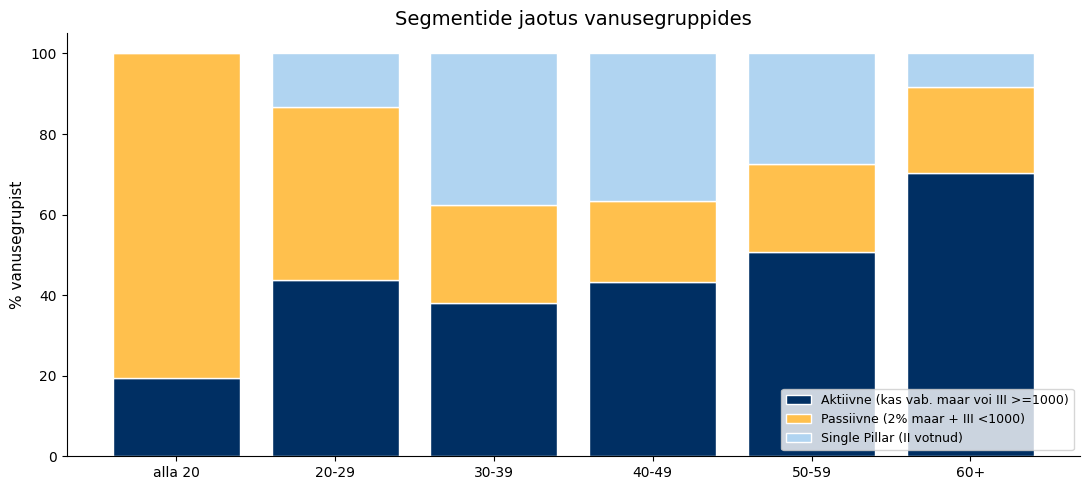

In [22]:
seg_age = pd.crosstab(cs["age_grp"], cs["segment"], normalize="index").reindex(age_labels) * 100
seg_age = seg_age[order]
print("=== Segmendi osakaal vanusegrupis (% reast) ===")
print(seg_age.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(age_labels))
seg_colors = [TULEVA_NAVY, "#FFC04D", REFERENCE_COLOR]
for seg, color in zip(order, seg_colors):
    vals = seg_age[seg].fillna(0).values
    ax.bar(age_labels, vals, bottom=bottom, label=seg, color=color, edgecolor="white")
    bottom += vals
ax.set_ylabel("% vanusegrupist")
ax.set_title("Segmentide jaotus vanusegruppides")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [23]:
cs["added_ii_after"] = added_ii_after
cs["active_in_tuleva_ii"] = cs[["Active In Tuk75", "Active In Tuk00"]].any(axis=1)

print("=== Aktiivsuse seos II samba uletoomisega ===\n")
rows = []
for seg in order:
    sub = cs[cs["segment"] == seg]
    n_seg = len(sub)
    brought = sub["added_ii_after"].sum()
    active_ii = sub["active_in_tuleva_ii"].sum()
    ii_aum = sub.loc[sub["added_ii_after"], ["Tuk75 Current Aum", "Tuk00 Current Aum"]].sum().sum() / 1e6
    rows.append({
        "Segment": seg,
        "inimesi": n_seg,
        "II toonud": brought,
        "II toonud %": brought / n_seg * 100,
        "Aktiivne Tuleva II": active_ii,
        "Aktiivne Tuleva II %": active_ii / n_seg * 100,
        "II AUM (M EUR)": ii_aum,
    })
seg_ii = pd.DataFrame(rows)
print(seg_ii.round(1).to_string(index=False))

eligible = cs[~left_ii_system]
elig_brought = eligible["added_ii_after"].sum()
print(f"\n=== Vorreldes uletoomise voimalikega (mitte-R/A) ===")
print(f"  Voimalikke (mitte II valja votnud): {len(eligible):,}")
print(f"  Tegelikult II Tulevasse toonud:     {elig_brought:,}  ({elig_brought/len(eligible)*100:.1f}% conversion)")

print(f"\n=== Aktiivsete vs passiivsete uletoomise vorrutus ===")
for seg in ["Aktiivne (kas vab. maar voi III >=1000)", "Passiivne (2% maar + III <1000)"]:
    sub = cs[cs["segment"] == seg]
    print(f"  {seg}: {sub['added_ii_after'].sum():,} / {len(sub):,} = {sub['added_ii_after'].mean()*100:.1f}%")

=== Aktiivsuse seos II samba uletoomisega ===



                                Segment  inimesi  II toonud  II toonud %  Aktiivne Tuleva II  Aktiivne Tuleva II %  II AUM (M EUR)
Aktiivne (kas vab. maar voi III >=1000)     2816        526         18.7                 465                  16.5             6.3
        Passiivne (2% maar + III <1000)     1810        246         13.6                 228                  12.6             1.3
              Single Pillar (II votnud)     1795        122          6.8                 118                   6.6             0.1

=== Vorreldes uletoomise voimalikega (mitte-R/A) ===
  Voimalikke (mitte II valja votnud): 4,626
  Tegelikult II Tulevasse toonud:     772  (16.7% conversion)

=== Aktiivsete vs passiivsete uletoomise vorrutus ===
  Aktiivne (kas vab. maar voi III >=1000): 526 / 2,816 = 18.7%
  Passiivne (2% maar + III <1000): 246 / 1,810 = 13.6%


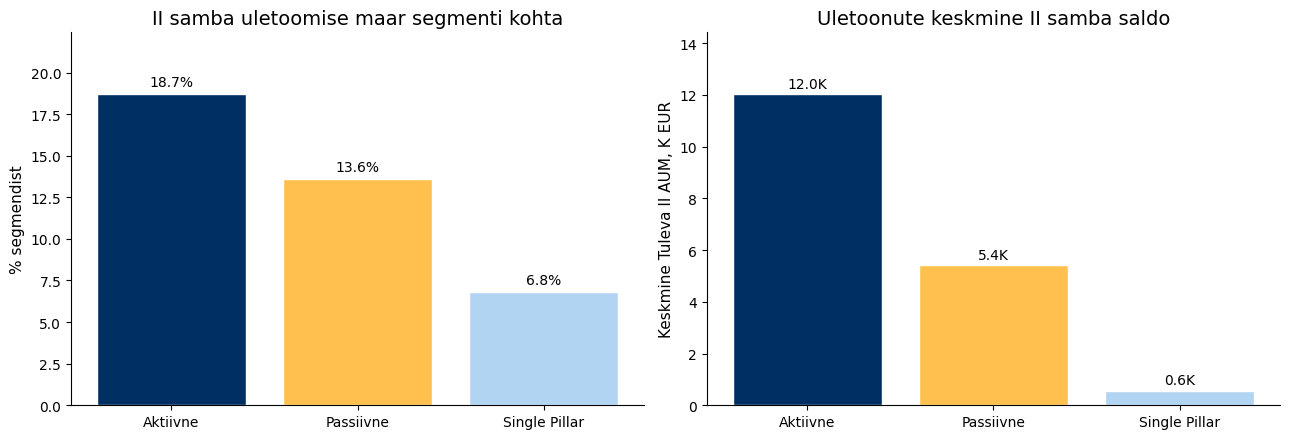

In [24]:
avg_ii_per_bringer = []
for seg in order:
    sub = cs[cs["segment"] == seg]
    bringers = sub[sub["added_ii_after"]]
    if len(bringers) > 0:
        avg = bringers[["Tuk75 Current Aum", "Tuk00 Current Aum"]].sum().sum() / len(bringers)
    else:
        avg = 0
    avg_ii_per_bringer.append(avg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
seg_short = ["Aktiivne", "Passiivne", "Single Pillar"]
pcts = [seg_ii.set_index("Segment").loc[s, "II toonud %"] for s in order]
bars = ax.bar(seg_short, pcts, color=[TULEVA_NAVY, "#FFC04D", REFERENCE_COLOR], edgecolor="white")
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{p:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("% segmendist")
ax.set_title("II samba uletoomise maar segmenti kohta")
ax.set_ylim(0, max(pcts) * 1.2)

ax = axes[1]
bars = ax.bar(seg_short, [a/1000 for a in avg_ii_per_bringer], color=[TULEVA_NAVY, "#FFC04D", REFERENCE_COLOR], edgecolor="white")
for bar, a in zip(bars, avg_ii_per_bringer):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_ii_per_bringer)*0.02/1000,
            f"{a/1000:.1f}K", ha="center", fontsize=10)
ax.set_ylabel("Keskmine Tuleva II AUM, K EUR")
ax.set_title("Uletoonute keskmine II samba saldo")
ax.set_ylim(0, max(avg_ii_per_bringer)/1000 * 1.2)

plt.tight_layout()
plt.show()

## Kokkuvõte — kes Tulevaga III sambast liituvad?

**Cohort:** 6,421 inimest, kes alustasid Tulevas kogumist III sambaga (esimene III sissemakse 2025-01-01 → 2026-04-30, ~50% kõigist Tuleva uutest kogujatest sel perioodil).

### Kolm peamist inimtüüpi

| Tüüp | Osakaal | Mediaan vanus | Kes nad on | III L12m mediaan | AUM panus |
|---|---|---|---|---|---|
| **Aktiivne säästja** | 44% (2,816) | 39 | 67% vabatahtlikul määral, 48% just 6%-l, 29% püsimaksega | 1,276 € | 17 M € (66%) |
| **Passiivne alustaja** | 28% (1,810) | 33 | Kõik 2% määral, väike sissemakse, 21% püsimaksega | 200 € | 2.5 M € (10%) |
| **Single Pillar** | 28% (1,795) | 39 | II sambast lahkunud (R/A) — III on ainus sammas | 300 € | 2.1 M € (8%) |

### Kas noorus ja II väljavõtmine kattuvad?

Suuresti ei. Need on osaliselt eri inimrühmad:

- **20-29-aastased** (23% cohort'ist): vaid 13% on II välja võtnud. Aga ka kõige passiivsem grupp — 43% jääb 2% määrale ja teeb III alla 1000 €. Pool noortest on nö "katsetajad" — väike sissemakse, jälle vaikne.
- **30-49-aastased** (54% cohort'ist): siin on II väljavõtjate kontsentratsioon kõrge (37%). Valdav osa Single Pillar segmentist on just selles vanuses. III sammas on neil kompensatsioon kaotatud II eest.
- **50+ vanuses** (20% cohort'ist): kõige aktiivsemad (51-70% aktiivsel režiimil). Vähem II väljavõtjaid, sest pensionifaasi lähedal.

Niisiis kaks paralleelset, peaaegu eraldiseisvat lugu:
1. **Noored alustajad** — III on esimene tutvus pensionisüsteemiga, sissemaksed väikesed, paljud passiivsed
2. **Keskealised II väljavõtjad** — III on plaan B, kuna II sammast pole

### Mis eristab aktiivseid passiivsetest?

Põhilised tunnused, mis korreleeruvad aktiivse käitumisega:
- **Vanus**: aktiivsete mediaan 39 vs passiivsete 33. Vanusega kasvab arusaamine ja kiireloomulisus.
- **II samba maksemäär**: aktiivsete seas 67% vabatahtlikul määral (peaaegu pool 6%-l) — sama signaalsüsteem mõlema samba jaoks. Inimene, kes on tõstnud II maksemäära, teeb tõenäoliselt ka tugevama III.
- **Püsimakse**: aktiivsetel 29%, passiivsetel 21% — automatiseerimine on sissemakse mahuga seotud.

Passiivsed = noor inimene, kes tegi väikese III sissemakse ("test"), pole II määra muutnud, püsimakset pole. See on grupp, kelle aktiveerimisel on kõige suurem upside — kui passiivsed jõuaks aktiivsete tasemeni, kasvaks cohort'i 12-kuu sissemakse maht ~7,8 → ~10 M €.

### Power Saver tuum

444 inimest (7%) vastab Power Saveri kriteeriumitele (mõlemad sambad + vabatahtlik määr + III ≥ 2400 € aastas) ja toob 27% cohort'i AUM-ist. Mediaan vanus 41, kõik 100% vabatahtlikul määral. Need on inimesed, kes kasutavad III sammast investeerimisinstrumendina, mitte sundosalusena.

### Andmekaveat

Sissetulekuandmeid puudub 90% cohort'ist (vs 56% varasematel kogujatel) — st cohort on Tuleva CRM-is veel "fresh" ega ole värsket palka veel kirjas. Edasises analüüsis võib palga kvaliteet paraneda kuude möödudes.